In [1]:
import h5py
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

SQRT_2PI = np.sqrt(2 * np.pi)

# -- Jackknife: generalized to arrays of shape (N_jk, ...), axis=0 -----------
def Jackknife(datalist):
    arr = np.asarray(datalist, dtype=float)
    N = arr.shape[0]
    theta_bar = arr.mean(axis=0)
    sigma_sq = ((N - 1) / N) * np.sum((arr - theta_bar) ** 2, axis=0)
    return theta_bar, np.sqrt(sigma_sq)

# -- Compact error formatter ---------------------------------------------
def fmt_err(mean, err):
    if err <= 0:
        return f"{mean}"
    if mean and (abs(mean) < 1e-3 or abs(mean) >= 1e3):
        exp = int(math.floor(math.log10(abs(mean))))
        ms = mean / 10**exp; es = err / 10**exp
        pl = int(math.floor(math.log10(abs(es))))
        nd = max(0, -(pl - 1))
        return f"{ms:.{nd}f}({int(round(es*10**nd))})e{exp}"
    else:
        pl = int(math.floor(math.log10(abs(err))))
        nd = max(0, -(pl - 1))
        return f"{mean:.{nd}f}({int(round(err*10**nd))})"

# -- H5 loader -------------------------------------------------------------
def load_params_from_h5(filename):
    fitted_params = {}
    with h5py.File(filename, "r") as f:
        for key in f["jackknife_samples"].keys():
            fitted_params[key] = f["jackknife_samples"][key][:]
        chi2_dof_list = f["chi2_dof"][:]
    return fitted_params, chi2_dof_list

# -- LaTeX / Markdown parameter table ---------------------------------------
def print_latex_table(fitted_params, chi2_dof_list, PL, bmin, etamin, etamax):
    res = {k: fmt_err(*Jackknife(v)) for k, v in fitted_params.items()}
    chi2_str = fmt_err(*Jackknife(chi2_dof_list))

    re_params   = ['a_re', 'c_re', 'd_re', 'j_re', 'k1_re', 'k2_re', 'f']
    im_params   = ['a_im', 'c_im', 'd_im', 'j_im', 'f']
    a12b_params = ['a_reA12B', 'c_reA12B', 'd_reA12B', 'j_reA12B', 'f']

    vals_re   = ", ".join(res[p] for p in re_params   if p in res)
    vals_im   = ", ".join(res[p] for p in im_params   if p in res)
    vals_a12b = ", ".join(res[p] for p in a12b_params if p in res)

    eq_re   = r"$\dfrac{a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$"
    eq_im   = r"$\dfrac{a\,\mathrm{Pb}\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$"
    eq_a12b = r"$\dfrac{-a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$"

    names_re   = "$\\{" + ", ".join(re_params)   + "\\}$"
    names_im   = "$\\{" + ", ".join(im_params)   + "\\}$"
    names_a12b = "$\\{" + ", ".join(a12b_params) + "\\}$"

    md  = "\n### ExpPb\_PowerLawb Simultaneous Fit (common $f$)\n"
    md += f"$P_L={PL}$,&nbsp; $b_{{\\min}}\\ge{bmin}a$,&nbsp; $\\eta\\in[{etamin},{etamax}]$\n\n"
    md += f"$\\chi^2/\\text{{DoF}} = {chi2_str}$ (Global)\n\n"
    md += "| Amplitude | Model Expression | Params | Fitted Values |\n"
    md += "| :--- | :--- | :--- | :--- |\n"
    md += f"| $\\tilde{{A}}_{{2B}}^{{\\text{{Re}}}}$ | {eq_re} | {names_re} | $[{vals_re}]$ |\n"
    md += f"| $\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}}$ | {eq_im} | {names_im} | $[{vals_im}]$ |\n"
    md += f"| $\\tilde{{A}}_{{12B}}^{{\\text{{Re}}}}$ | {eq_a12b} | {names_a12b} | $[{vals_a12b}]$ |\n"

    try:
        display(Markdown(md))
    except Exception:
        print(md)

# -- Main FT + integration table + 6-panel plot -----------------------------
def re_tilde(a, c, bpart, x):
    return a[:, None] * bpart[:, None] * np.sqrt(2/np.pi) * c[:, None] / (c[:, None]**2 + x[None, :]**2)

def im_evals_fn(a, c, bpart, x):
    # im_evals(x) := i * ImA2B~(x)  (real-valued; matches reference row-2 convention)
    return -a[:, None] * bpart[:, None] * 2*np.sqrt(2/np.pi) * c[:, None] * x[None, :] / (c[:, None]**2 + x[None, :]**2)**2

def A_at_zero(a, c, bpart):
    return a * bpart

def plot_fourier_transforms_A2B_A12B(fitted_params, chi2_dof_list, b2, PL,
                                      bminfit, etamin, etamax, num_points=200):
    print_latex_table(fitted_params, chi2_dof_list, PL, bminfit, etamin, etamax)

    x_vals = np.linspace(-1, 1, num_points)

    MassN    = 0.6228
    lata     = 0.11403
    massterm = MassN * (197.0 * 0.001 / lata)

    b = np.sqrt(b2)   # fixed Lorentz-invariant |b| (b^2 = bL^2 + bT^2 held fixed)

    # -- Jackknife parameter arrays, shape (N_jk,) ---------------------------
    a_re  = np.array(fitted_params['a_re'])
    c_re  = np.array(fitted_params['c_re'])
    d_re  = np.array(fitted_params['d_re'])

    a_im  = np.array(fitted_params['a_im'])
    c_im  = np.array(fitted_params['c_im'])
    d_im  = np.array(fitted_params['d_im'])

    a_reA12B = -np.array(fitted_params['a_reA12B'])   # sign flip already in the model
    c_reA12B =  np.array(fitted_params['c_reA12B'])
    d_reA12B =  np.array(fitted_params['d_reA12B'])
    j_re     = np.array(fitted_params['j_re'])
    j_im     = np.array(fitted_params['j_im'])
    j_reA12B = np.array(fitted_params['j_reA12B'])

    bpart_re    = (1.0 + d_re * b2) ** (-j_re)
    bpart_im    = (1.0 + d_im * b2) ** (-j_im)
    bpart_a12b  = (1.0 + d_reA12B * b2) ** (-j_reA12B)

    # =========================================================================
    # Integration table (all rows fully analytic; only the finite x-ranges
    # need a trivial 1D numerical integration of the closed-form curve)
    # =========================================================================
    print("\nEvaluating analytical Fourier transforms across Jackknife samples...")

    # {-inf, +inf}: exact via Parseval, Integral Atilde(x) dx = sqrt(2*pi)*A(lambda=0)
    int_inf_re   = SQRT_2PI * A_at_zero(a_re,      c_re,      bpart_re)
    int_inf_im   = np.zeros_like(a_im)                        # odd -> A_im(0) = 0
    int_inf_a12b = SQRT_2PI * A_at_zero(a_reA12B,  c_reA12B,  bpart_a12b)

    x_fine = np.linspace(-1, 1, 1000)
    re_xf   = re_tilde(a_re,      c_re,      bpart_re,   x_fine)   # (N_jk, 1000)
    im_xf   = im_evals_fn(a_im,   c_im,      bpart_im,   x_fine)
    a12b_xf = re_tilde(a_reA12B,  c_reA12B,  bpart_a12b, x_fine)

    m11  = (x_fine >= -1) & (x_fine <= 1)
    mm10 = (x_fine >= -1) & (x_fine <= 0)
    m01  = (x_fine >= 0)  & (x_fine <= 1)

    int_11_re    = np.trapz(re_xf[:,  m11],  x=x_fine[m11],  axis=1)
    int_m10_re   = np.trapz(re_xf[:,  mm10], x=x_fine[mm10], axis=1)
    int_01_re    = np.trapz(re_xf[:,  m01],  x=x_fine[m01],  axis=1)

    int_11_im    = np.trapz(im_xf[:,  m11],  x=x_fine[m11],  axis=1)
    int_m10_im   = np.trapz(im_xf[:,  mm10], x=x_fine[mm10], axis=1)
    int_01_im    = np.trapz(im_xf[:,  m01],  x=x_fine[m01],  axis=1)

    int_11_a12b  = np.trapz(a12b_xf[:, m11],  x=x_fine[m11],  axis=1)
    int_m10_a12b = np.trapz(a12b_xf[:, mm10], x=x_fine[mm10], axis=1)
    int_01_a12b  = np.trapz(a12b_xf[:, m01],  x=x_fine[m01],  axis=1)

    res_re  = [int_inf_re,   int_11_re,   int_m10_re,   int_01_re]
    res_im  = [int_inf_im,   int_11_im,   int_m10_im,   int_01_im]
    res_f1  = [2*(res_re[i] - res_im[i]) for i in range(4)]
    res_f1T = [-2*int_inf_a12b, -2*int_11_a12b, -2*int_m10_a12b, -2*int_01_a12b]
    res_siv = [massterm * res_f1T[i] / res_f1[i] for i in range(4)]

    def format_jk(data):
        m, e = Jackknife(data)
        return fmt_err(m, e)

    row1 = [format_jk(d) for d in res_re]
    row2 = [format_jk(d) for d in res_im]
    row3 = [format_jk(d) for d in res_f1]
    row4 = [format_jk(d) for d in res_f1T]
    row5 = [format_jk(d) for d in res_siv]

    md_int  = "\n### Analytical Fourier Transform Integration Table\n\n"
    md_int += "| Integral | $\\{-\\infty,\\infty\\}$ | $\\{-1,1\\}$ | $\\{-1,0\\}$ | $\\{0,1\\}$ |\n"
    md_int += "| :--- | :--- | :--- | :--- | :--- |\n"
    md_int += (f"| $\\int dx\\,\\tilde{{A}}_{{2B}}^{{\\text{{Re}}}}$ "
               f"| {row1[0]} | {row1[1]} | {row1[2]} | {row1[3]} |\n")
    md_int += (f"| $\\int dx\\,(i\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}})$ "
               f"| {row2[0]} | {row2[1]} | {row2[2]} | {row2[3]} |\n")
    md_int += (f"| $\\tilde{{f}}_1^{{(0)}}=2\\int dx\\,"
               f"(\\tilde{{A}}_{{2B}}^{{\\text{{Re}}}}"
               f"-i\\tilde{{A}}_{{2B}}^{{\\text{{Im}}}})$ "
               f"| {row3[0]} | {row3[1]} | {row3[2]} | {row3[3]} |\n")
    md_int += (f"| $\\tilde{{f}}_{{1T}}^{{\\perp(1)}}=-2\\int dx\\,"
               f"\\tilde{{A}}_{{12B}}$ "
               f"| {row4[0]} | {row4[1]} | {row4[2]} | {row4[3]} |\n")
    md_int += (f"| $m_N\\dfrac{{\\tilde{{f}}_{{1T}}^{{\\perp(1)}}}}"
               f"{{\\tilde{{f}}_1^{{(0)}}}}$ "
               f"| {row5[0]} | {row5[1]} | {row5[2]} | {row5[3]} |\n")

    try:
        display(Markdown(md_int))
    except Exception:
        print(md_int)

    # =========================================================================
    # Plotting -- fully vectorized analytic evaluation over x_vals
    # =========================================================================
    re_v   = re_tilde(a_re,      c_re,      bpart_re,   x_vals)   # (N_jk, num_points)
    im_v   = im_evals_fn(a_im,   c_im,      bpart_im,   x_vals)
    a12b_v = re_tilde(a_reA12B,  c_reA12B,  bpart_a12b, x_vals)

    full_v = 2 * (re_v - im_v)
    f1T_v  = -2 * a12b_v
    siv_v  = massterm * f1T_v / full_v
    xsiv_v = x_vals[None, :] * siv_v

    re_mean,     re_err     = Jackknife(re_v)
    im_mean,     im_err     = Jackknife(im_v)
    full_mean,   full_err   = Jackknife(full_v)
    reA12B_mean, reA12B_err = Jackknife(f1T_v)
    SivShift_mean,  SivShift_err  = Jackknife(siv_v)
    xSivShift_mean, xSivShift_err = Jackknife(xsiv_v)

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(14, 8))

    ax1.plot(x_vals, re_mean, color='blue', label='ReA2B Mean')
    ax1.fill_between(x_vals, re_mean-re_err, re_mean+re_err, color='blue', alpha=0.3)
    ax1.set_title(f'$\\tilde{{A}}_{{2B}}^{{Re}}$ ($P_L$={PL}, $b^2$={b2})')
    ax1.set_xlabel('$x$'); ax1.set_ylabel('$\\tilde{A}_{2B}^{Re}$')
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(x_vals, im_mean, color='red', label='ImA2B Mean')
    ax2.fill_between(x_vals, im_mean-im_err, im_mean+im_err, color='red', alpha=0.3)
    ax2.set_title(f'$i\\tilde{{A}}_{{2B}}^{{Im}}$ ($P_L$={PL}, $b^2$={b2})')
    ax2.set_xlabel('$x$'); ax2.set_ylabel('$i\\tilde{A}_{2B}^{Im}$')
    ax2.grid(True, linestyle='--', alpha=0.6)

    ax3.plot(x_vals, full_mean, color='green', label='A2B Mean')
    ax3.fill_between(x_vals, full_mean-full_err, full_mean+full_err, color='green', alpha=0.3)
    ax3.set_title(f'$\\tilde{{f}}_{{1}}^{{(0)}}=2\\tilde{{A}}_{{2B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax3.set_xlabel('$x$'); ax3.set_ylabel('$\\tilde{f}_{1}^{(0)}$')
    ax3.grid(True, linestyle='--', alpha=0.6)

    ax4.plot(x_vals, reA12B_mean, color='blue')
    ax4.fill_between(x_vals, reA12B_mean-reA12B_err, reA12B_mean+reA12B_err,
                     color='blue', alpha=0.3)
    ax4.set_title(f'$\\tilde{{f}}_{{1}}^{{\\perp(1)}}=-2\\tilde{{A}}_{{12B}}$ ($P_L$={PL}, $b^2$={b2})')
    ax4.set_xlabel('$x$'); ax4.set_ylabel('$\\tilde{f}_{1}^{\\perp(1)}$')
    ax4.grid(True, linestyle='--', alpha=0.6)

    mask = x_vals >= 0

    ax5.plot(x_vals[mask], SivShift_mean[mask], color='blue')
    ax5.fill_between(x_vals[mask],
                     SivShift_mean[mask]-SivShift_err[mask],
                     SivShift_mean[mask]+SivShift_err[mask],
                     color='blue', alpha=0.3)
    ax5.set_title(f'$\\langle k_{{y}}\\rangle_{{TU}}$ (GeV) ($P_L$={PL}, $b^2$={b2})')
    ax5.set_xlabel('$x$'); ax5.set_ylabel('$\\langle k_{y}\\rangle_{TU}$ (GeV)')
    ax5.grid(True, linestyle='--', alpha=0.6)

    ax6.plot(x_vals[mask], xSivShift_mean[mask], color='blue')
    ax6.fill_between(x_vals[mask],
                     xSivShift_mean[mask]-xSivShift_err[mask],
                     xSivShift_mean[mask]+xSivShift_err[mask],
                     color='blue', alpha=0.3)
    ax6.set_title(f'$x\\langle k_{{y}}\\rangle_{{TU}}$ (GeV) ($P_L$={PL}, $b^2$={b2})')
    ax6.set_xlabel('$x$'); ax6.set_ylabel('$x\\langle k_{y}\\rangle_{TU}$ (GeV)')
    ax6.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    param_keys_str = "-".join(fitted_params.keys())
    file_name = (f"SimulFitCovMatrix-A12B-A2B-FT-{param_keys_str}"
                 f"__bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.pdf")
    plt.savefig(file_name, format='pdf', bbox_inches='tight')
    plt.show()
    return



### ExpPb\_PowerLawb Simultaneous Fit (common $f$)
$P_L=-1$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 1.286(89)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $\dfrac{a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_re, c_re, d_re, j_re, k1_re, k2_re, f\}$ | $[2.38(11), 0.668(59), 0.1054(83), 1.786(53), 11.14(18), -30.7(10), 0.4299(43)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $\dfrac{a\,\mathrm{Pb}\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_im, c_im, d_im, j_im, f\}$ | $[-0.167(31), 0.004(25), 0.123(32), 1.57(14), 0.4299(43)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $\dfrac{-a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_reA12B, c_reA12B, d_reA12B, j_reA12B, f\}$ | $[0.784(76), 0.028(24), 0.105(16), 2.03(15), 0.4299(43)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 1.815(44) | 1.135(59) | 0.566(29) | 0.566(29) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | 3(52)e-14 | -9(42) | 9(42) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 3.630(88) | 2.27(12) | 18(84) | -16(84) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 1.020(62) | 1.001(60) | 0.489(30) | 0.489(30) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.302(17) | 0.475(34) | 0.03(13) | -0.03(17) |


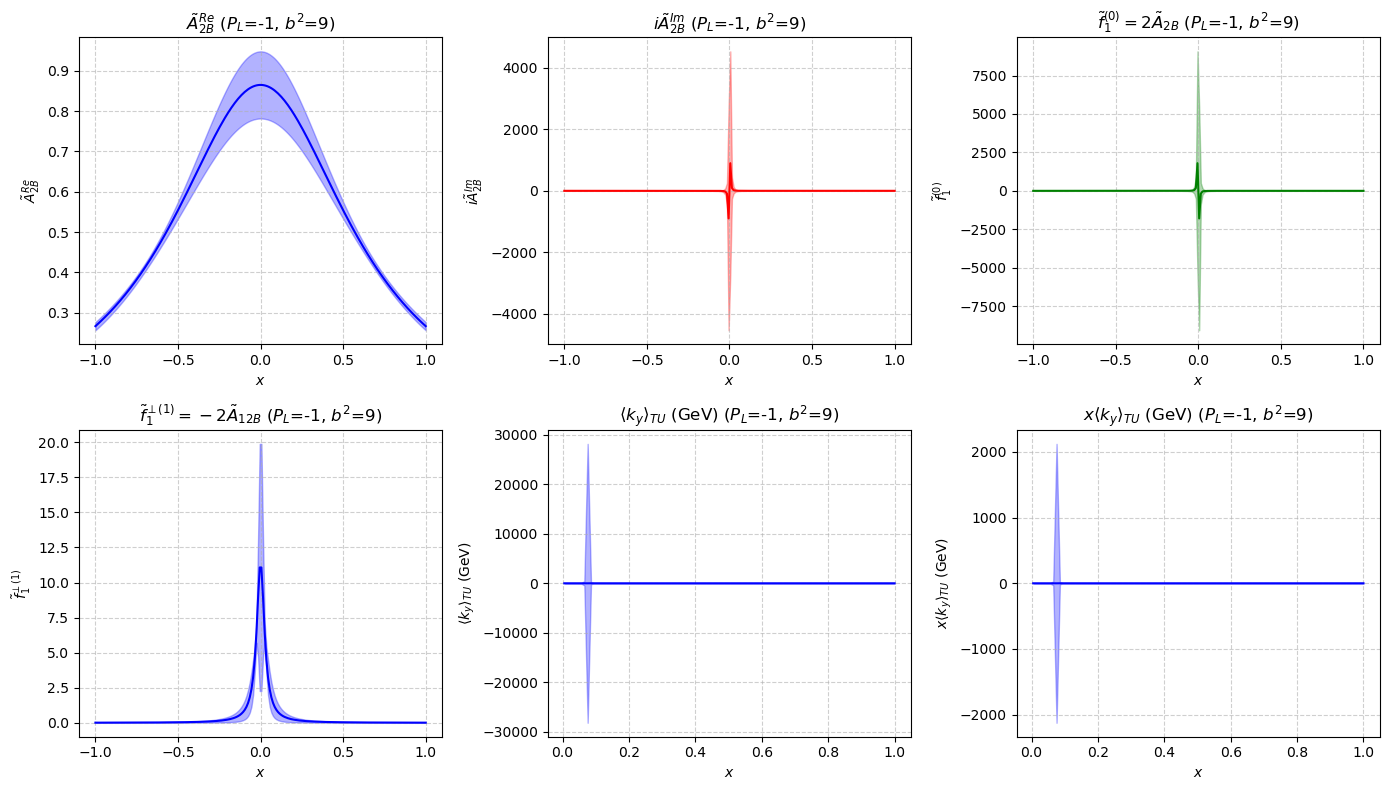

In [2]:
b2      = 9
PL      = -1
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_ExpPb_PowerLawb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### ExpPb\_PowerLawb Simultaneous Fit (common $f$)
$P_L=-1$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 1.286(89)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $\dfrac{a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_re, c_re, d_re, j_re, k1_re, k2_re, f\}$ | $[2.38(11), 0.668(59), 0.1054(83), 1.786(53), 11.14(18), -30.7(10), 0.4299(43)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $\dfrac{a\,\mathrm{Pb}\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_im, c_im, d_im, j_im, f\}$ | $[-0.167(31), 0.004(25), 0.123(32), 1.57(14), 0.4299(43)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $\dfrac{-a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_reA12B, c_reA12B, d_reA12B, j_reA12B, f\}$ | $[0.784(76), 0.028(24), 0.105(16), 2.03(15), 0.4299(43)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 0.2252(83) | 0.1408(80) | 0.0703(40) | 0.0703(40) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | 5(75)e-15 | -1.3(60) | 1.3(60) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 0.450(17) | 0.282(16) | 3(12) | -2(12) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 0.095(13) | 0.094(12) | 0.0458(62) | 0.0458(62) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.228(31) | 0.358(48) | 0.019(82) | -0.02(10) |


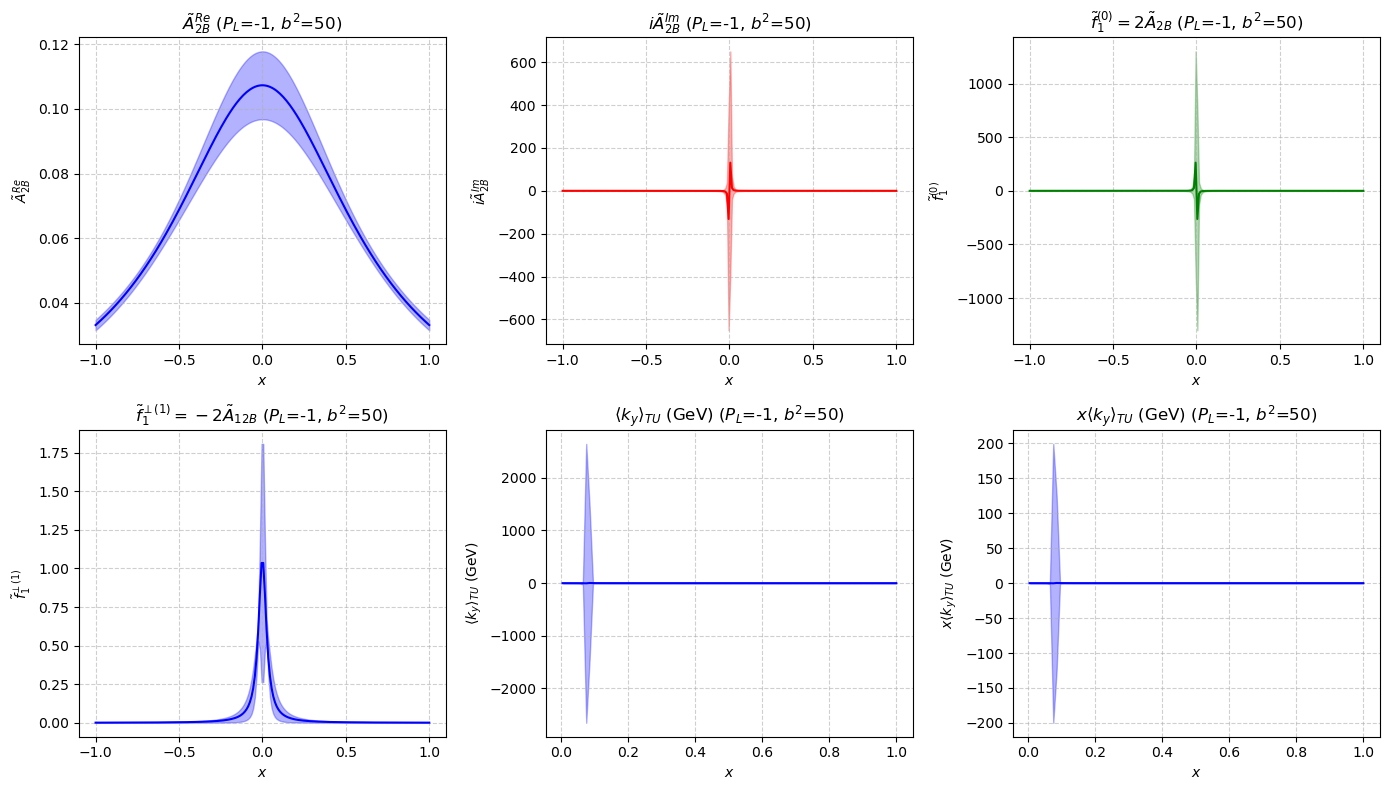

In [3]:
b2      = 50
PL      = -1
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_ExpPb_PowerLawb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### ExpPb\_PowerLawb Simultaneous Fit (common $f$)
$P_L=-2$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 0.938(75)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $\dfrac{a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_re, c_re, d_re, j_re, k1_re, k2_re, f\}$ | $[2.79(22), 0.254(50), 0.0667(85), 2.47(16), 10.72(31), -27.8(15), 0.503(10)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $\dfrac{a\,\mathrm{Pb}\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_im, c_im, d_im, j_im, f\}$ | $[-0.190(35), 0.006(13), 0.096(25), 1.75(16), 0.503(10)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $\dfrac{-a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_reA12B, c_reA12B, d_reA12B, j_reA12B, f\}$ | $[0.801(78), -0.011(16), 0.077(10), 2.52(18), 0.503(10)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 2.19(12) | 1.84(14) | 0.919(72) | 0.919(72) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | 1(14)e-14 | -8(17) | 8(17) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 4.38(25) | 3.69(29) | 18(34) | -15(34) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 1.063(89) | -1.055(92) | -0.497(47) | -0.497(47) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.261(18) | -0.308(26) | -0.029(53) | 0.036(82) |


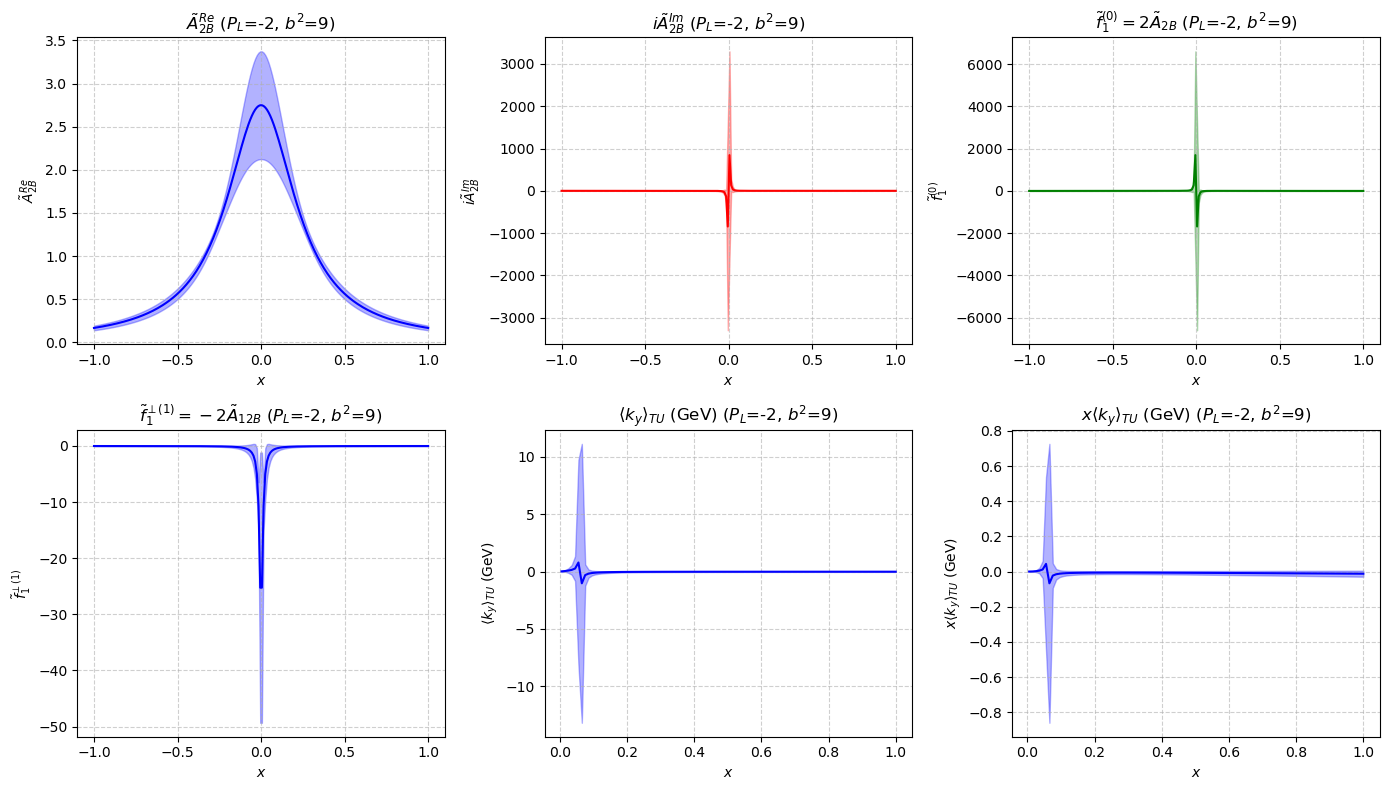

In [4]:
b2      = 9
PL      = -2
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_ExpPb_PowerLawb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### ExpPb\_PowerLawb Simultaneous Fit (common $f$)
$P_L=-3$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 0.623(61)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $\dfrac{a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_re, c_re, d_re, j_re, k1_re, k2_re, f\}$ | $[2.54(37), 0.293(96), 0.0601(82), 3.03(18), 11.64(39), -32.3(17), 0.520(21)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $\dfrac{a\,\mathrm{Pb}\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_im, c_im, d_im, j_im, f\}$ | $[-0.197(30), 0.021(17), 0.141(19), 1.55(19), 0.520(21)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $\dfrac{-a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_reA12B, c_reA12B, d_reA12B, j_reA12B, f\}$ | $[0.525(95), -0.020(19), 0.101(19), 2.14(19), 0.520(21)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 1.71(21) | 1.40(21) | 0.70(10) | 0.70(10) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -4(1881)e-17 | -2.0(14) | 2.0(14) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 3.43(42) | 2.81(41) | 5.5(28) | -2.7(28) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 0.66(12) | -0.65(12) | -0.316(55) | -0.316(55) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.207(32) | -0.250(43) | -0.062(32) | 0.13(13) |


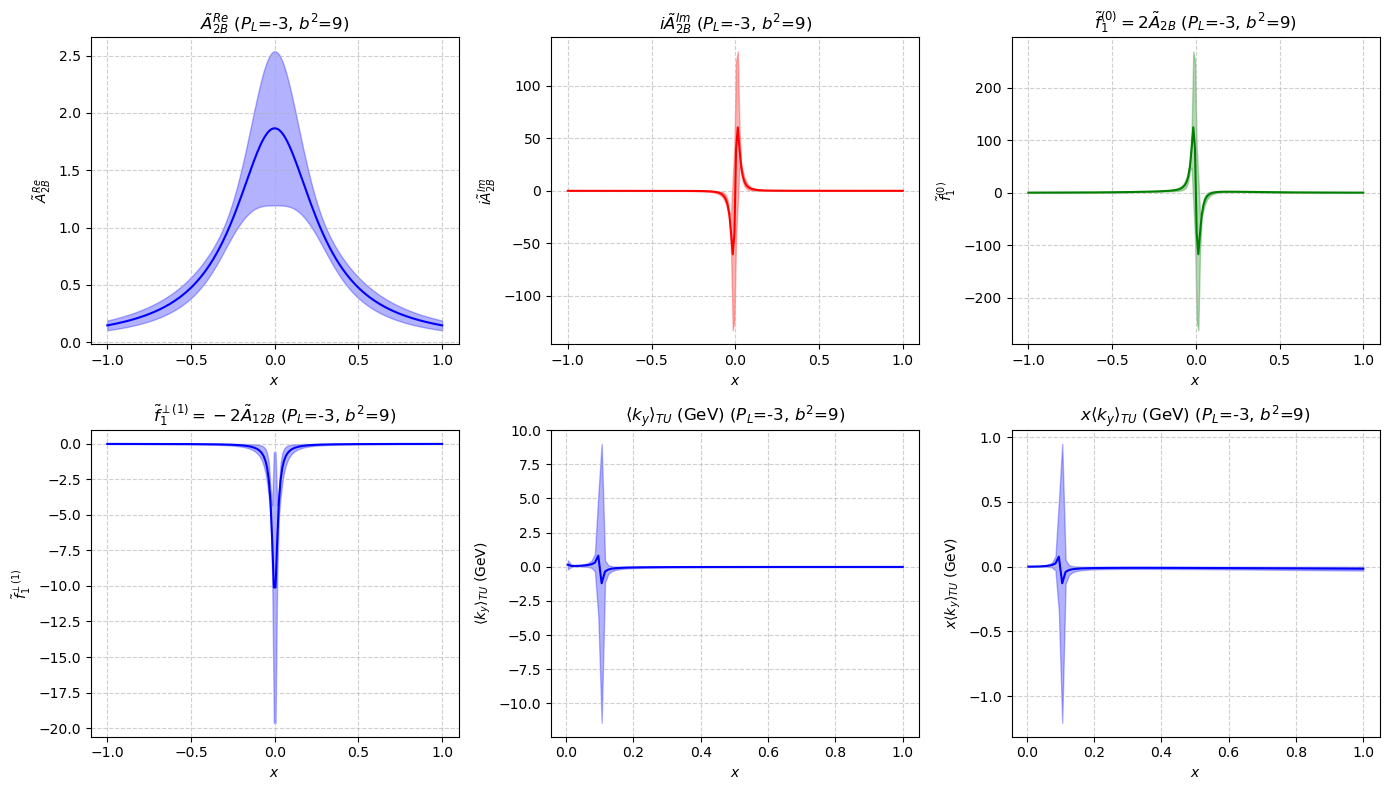

In [5]:
b2      = 9
PL      = -3
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_ExpPb_PowerLawb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### ExpPb\_PowerLawb Simultaneous Fit (common $f$)
$P_L=-4$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 0.447(53)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $\dfrac{a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_re, c_re, d_re, j_re, k1_re, k2_re, f\}$ | $[3.51(39), 0.337(77), 0.092(16), 2.34(18), 12.00(40), -35.3(19), 0.581(41)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $\dfrac{a\,\mathrm{Pb}\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_im, c_im, d_im, j_im, f\}$ | $[0.212(27), 0.422(18), 0.2109(48), 1.111(44), 0.581(41)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $\dfrac{-a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_reA12B, c_reA12B, d_reA12B, j_reA12B, f\}$ | $[0.519(58), 0.005(38), 0.106(28), 2.18(13), 0.581(41)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 2.15(51) | 1.70(41) | 0.85(21) | 0.85(21) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -2(3312)e-18 | 0.105(25) | -0.105(25) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 4.3(10) | 3.41(82) | 1.49(40) | 1.91(42) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 0.60(22) | 0.60(22) | 0.26(28) | 0.26(28) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.151(52) | 0.189(66) | 0.19(20) | 0.15(15) |


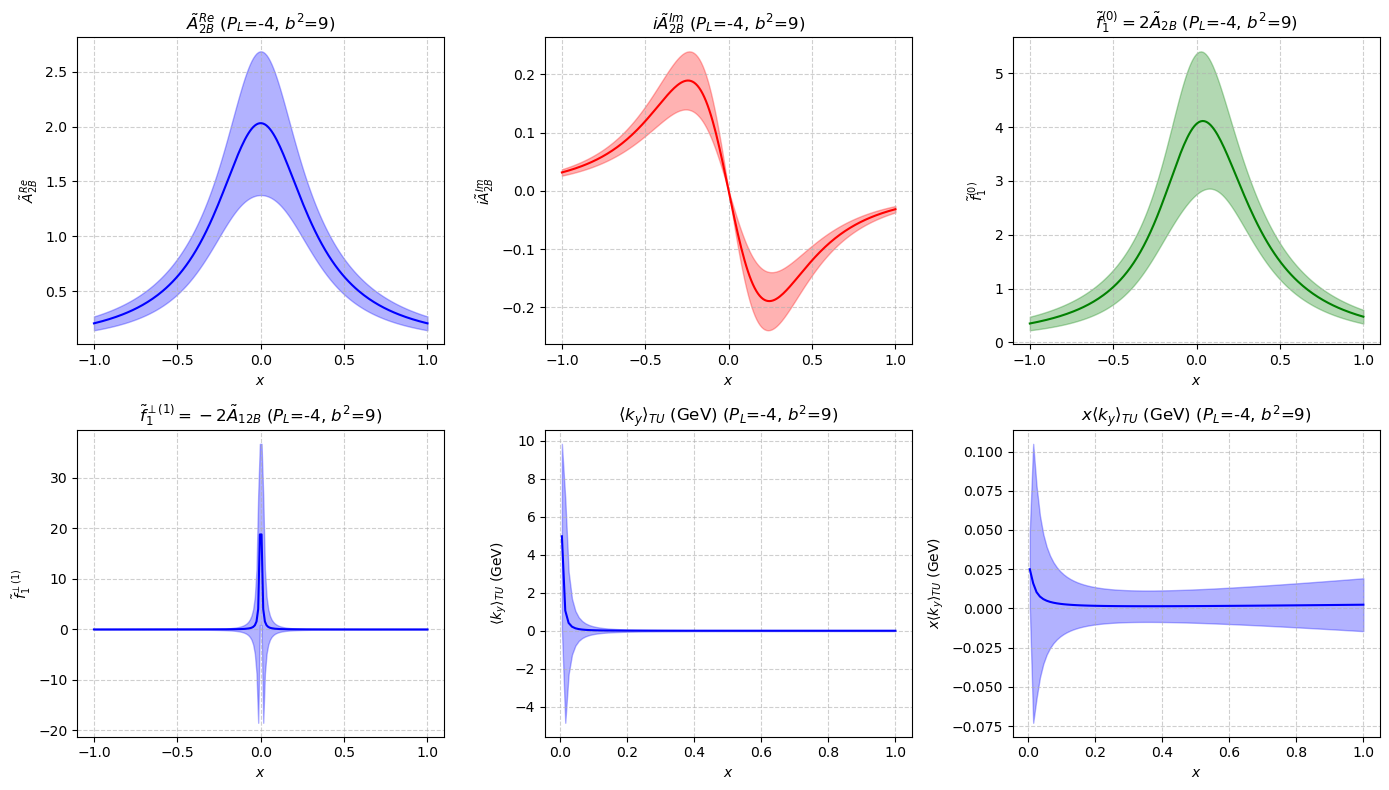

In [6]:
b2      = 9
PL      = -4
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_ExpPb_PowerLawb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)



### ExpPb\_PowerLawb Simultaneous Fit (common $f$)
$P_L=-4$,&nbsp; $b_{\min}\ge3a$,&nbsp; $\eta\in[6,10]$

$\chi^2/\text{DoF} = 0.447(53)$ (Global)

| Amplitude | Model Expression | Params | Fitted Values |
| :--- | :--- | :--- | :--- |
| $\tilde{A}_{2B}^{\text{Re}}$ | $\dfrac{a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_re, c_re, d_re, j_re, k1_re, k2_re, f\}$ | $[3.51(39), 0.337(77), 0.092(16), 2.34(18), 12.00(40), -35.3(19), 0.581(41)]$ |
| $\tilde{A}_{2B}^{\text{Im}}$ | $\dfrac{a\,\mathrm{Pb}\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_im, c_im, d_im, j_im, f\}$ | $[0.212(27), 0.422(18), 0.2109(48), 1.111(44), 0.581(41)]$ |
| $\tilde{A}_{12B}^{\text{Re}}$ | $\dfrac{-a\,\exp(-c\lvert\mathrm{Pb}\rvert)}{(1+d\,b^2)^{j}}$ | $\{a_reA12B, c_reA12B, d_reA12B, j_reA12B, f\}$ | $[0.519(58), 0.005(38), 0.106(28), 2.18(13), 0.581(41)]$ |



Evaluating analytical Fourier transforms across Jackknife samples...



### Analytical Fourier Transform Integration Table

| Integral | $\{-\infty,\infty\}$ | $\{-1,1\}$ | $\{-1,0\}$ | $\{0,1\}$ |
| :--- | :--- | :--- | :--- | :--- |
| $\int dx\,\tilde{A}_{2B}^{\text{Re}}$ | 0.29(12) | 0.229(95) | 0.114(48) | 0.114(48) |
| $\int dx\,(i\tilde{A}_{2B}^{\text{Im}})$ | 0.0 | -1(9062)e-19 | 0.0313(90) | -0.0313(90) |
| $\tilde{f}_1^{(0)}=2\int dx\,(\tilde{A}_{2B}^{\text{Re}}-i\tilde{A}_{2B}^{\text{Im}})$ | 0.58(24) | 0.46(19) | 0.166(93) | 0.29(10) |
| $\tilde{f}_{1T}^{\perp(1)}=-2\int dx\,\tilde{A}_{12B}$ | 0.084(51) | 0.083(50) | 0.037(46) | 0.037(46) |
| $m_N\dfrac{\tilde{f}_{1T}^{\perp(1)}}{\tilde{f}_1^{(0)}}$ | 0.156(93) | 0.20(12) | 0.24(30) | 0.14(16) |


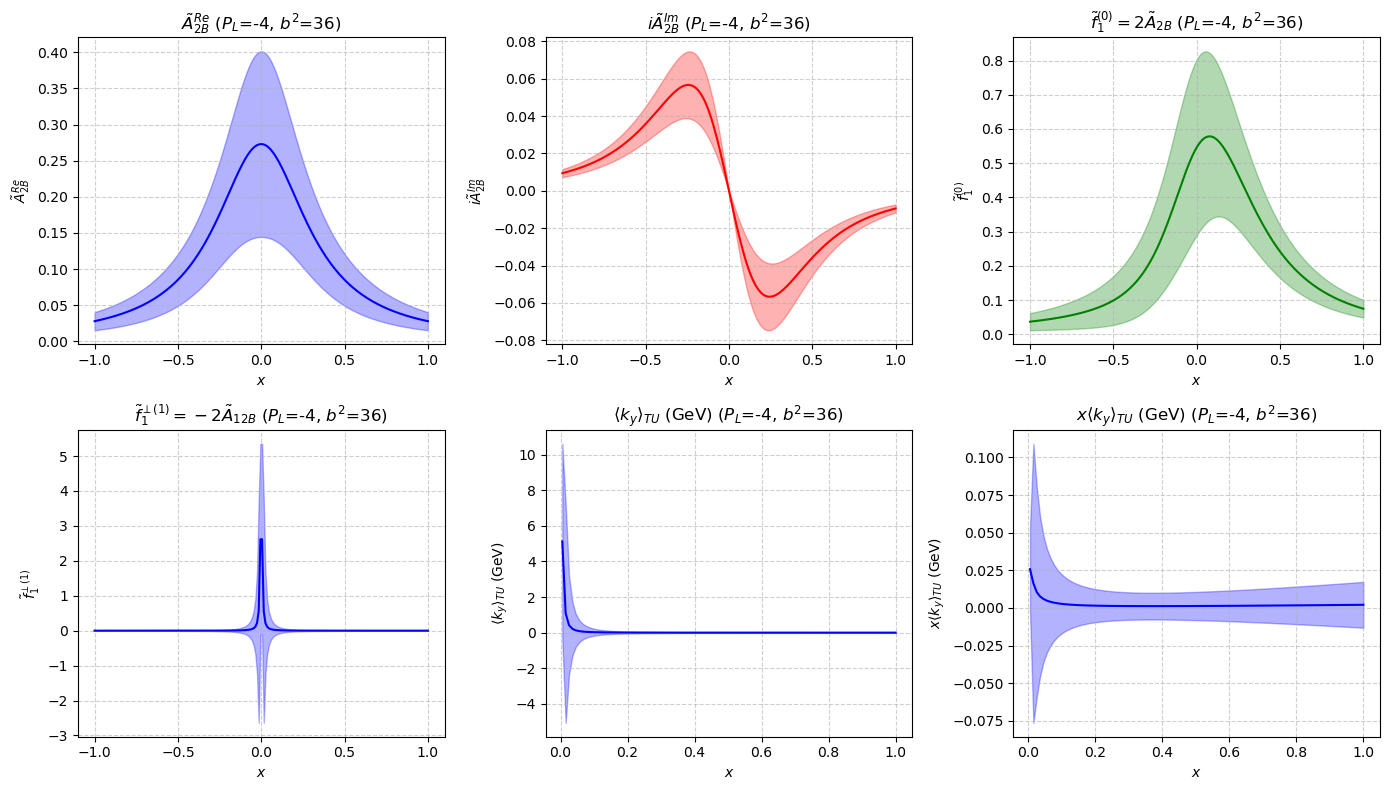

In [7]:
b2      = 36
PL      = -4
bminfit = 3
etamin  = 6
etamax  = 10

fitted_params, chi2_dof_list = load_params_from_h5(
    f"/Users/hariprashadravikumar/Lattice_QCD_TMD_PhD/sivers_TMD_PhD_project/save_h5_A12B_A2B/h5data/FitParams_SimulFit_ExpPb_PowerLawb_bmin{bminfit}_eta{etamin}{etamax}_PL{PL}.h5")

plot_fourier_transforms_A2B_A12B(
    fitted_params, chi2_dof_list, b2, PL, bminfit, etamin, etamax)
